<a href="https://colab.research.google.com/github/AyleenSantander/PProj/blob/main/Project_NYC_Airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Final Project: "New York City Airbnb Open Dataset"
# Question: How does the number of reviews relate to the price, availability, or other features of the listing?
#Import all tools need to use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import savefig
from pygments.lexers import clean
from sklearn.preprocessing import LabelEncoder

In [3]:
#Data Inspection
AB_NYC= pd.read_csv('AB_NYC_2019.csv')
#inspection
print(AB_NYC.info)
print(AB_NYC.shape) #48895 rows/instances and 16 columns/features
print(AB_NYC.columns)
print(AB_NYC.dtypes)  #str, float64, int64
print(AB_NYC.isnull().sum()) # name, host_name,last_review, reviews_per_month
print(AB_NYC.duplicated().sum())
print(AB_NYC.describe())
print(AB_NYC.head())

<bound method DataFrame.info of              id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

       

In [4]:
#Clone data
clone_AB_NYC = AB_NYC.copy()
print(clone_AB_NYC.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
#Fix room_type and neighbourhood_group
#check the values
print(sorted(clone_AB_NYC['room_type'].unique()))
print(sorted(clone_AB_NYC['neighbourhood_group'].unique()))

['Entire home/apt', 'Private room', 'Shared room']
['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']


In [8]:
#Fix room_type and neighbourhood_group
#check the values
print(sorted(clone_AB_NYC['room_type'].unique()))
print(sorted(clone_AB_NYC['neighbourhood_group'].unique()))

#mapping
room_type_map = {0: 'Entire home/apt', 1: 'Private room', 2: 'Shared room'}
neighbourhood_group_map = {0: 'Bronx', 1: 'Brooklyn', 2: 'Manhattan', 3: 'Queens', 4: 'Staten Island'}


clone_AB_NYC['room_type_label'] = clone_AB_NYC['room_type'].map(room_type_map)
clone_AB_NYC['neighbourhood_group_label']= clone_AB_NYC['neighbourhood_group'].map(neighbourhood_group_map)

print(clone_AB_NYC['room_type_label'].unique())
print(clone_AB_NYC['neighbourhood_group_label'].unique())

clone_AB_NYC['number_of_reviews'] = pd.to_numeric(
    clone_AB_NYC['number_of_reviews'], errors='coerce'
)
clone_AB_NYC['number_of_reviews'] = clone_AB_NYC['number_of_reviews'].fillna(
    clone_AB_NYC['number_of_reviews'].median()
)

['Entire home/apt', 'Private room', 'Shared room']
['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
[nan]
[nan]


In [12]:
clone_AB_NYC['number_of_reviews'] = pd.to_numeric(
    clone_AB_NYC['number_of_reviews'], errors='coerce'
)
clone_AB_NYC['number_of_reviews'] = clone_AB_NYC['number_of_reviews'].fillna(
    clone_AB_NYC['number_of_reviews'].median()
)

In [13]:
# Reverse maps matching previous run
room_type_map = {0: 'Private room', 1: 'Entire home/apt', 2: 'Shared room'}
neighbourhood_group_map = {1: 'Brooklyn', 2: 'Manhattan', 3: 'Queens', 4: 'Bronx', 5: 'Staten Island'}

clone_AB_NYC['room_type_label'] = clone_AB_NYC['room_type'].map(room_type_map)
clone_AB_NYC['neighbourhood_group_label'] = clone_AB_NYC['neighbourhood_group'].map(neighbourhood_group_map)

In [14]:
# Verify mapping
print(clone_AB_NYC['room_type_label'].unique())
print(clone_AB_NYC['neighbourhood_group_label'].unique())
print(clone_AB_NYC['number_of_reviews'].median())
print(clone_AB_NYC['number_of_reviews'].mean())

[nan]
[nan]
5.0
23.274465691788528


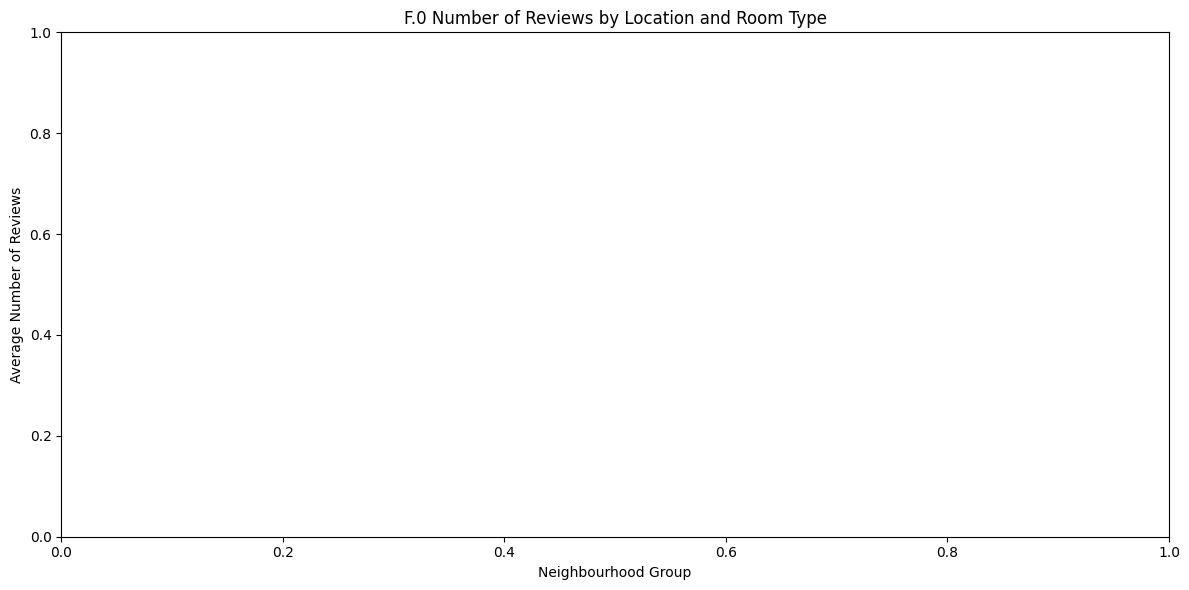

In [39]:
# Plot mapping
plt.figure(figsize=(12, 6))
sns.barplot(x='neighbourhood_group_label',
            y='number_of_reviews',
            hue='room_type_label',
            data=clone_AB_NYC.dropna(subset=['room_type_label', 'neighbourhood_group_label']),
            palette='coolwarm')
plt.title('F.0 Number of Reviews by Location and Room Type')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Number of Reviews')
plt.tight_layout()

# plt.savefig("F.0 Number of Reviews by Location and Room Type.png")
plt.show()
plt.close()

In [16]:
# Check after mapping
print(clone_AB_NYC['room_type'].isnull().sum())
print(clone_AB_NYC['neighbourhood_group'].isnull().sum())

0
0


In [17]:
#Drop variable we not used in this analysis
clone_AB_NYC = clone_AB_NYC.drop(columns=['id', 'host_id', 'host_name',
       'neighbourhood',  'latitude', 'longitude',  'last_review',
       'reviews_per_month', 'calculated_host_listings_count'])
print(clone_AB_NYC.columns.tolist())
print(clone_AB_NYC.shape)

['name', 'neighbourhood_group', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365', 'room_type_label', 'neighbourhood_group_label']
(48895, 9)


In [18]:
#Numerical Summarization (descriptive statistics of dataset)
print(clone_AB_NYC[['price','minimum_nights','number_of_reviews','availability_365']].describe())
print(clone_AB_NYC['number_of_reviews'].value_counts().sum())
print(clone_AB_NYC['availability_365'].value_counts().sum())
print(clone_AB_NYC['price'].value_counts().sum())

              price  minimum_nights  number_of_reviews  availability_365
count  48895.000000    48895.000000       48895.000000      48895.000000
mean     152.720687        7.029962          23.274466        112.781327
std      240.154170       20.510550          44.550582        131.622289
min        0.000000        1.000000           0.000000          0.000000
25%       69.000000        1.000000           1.000000          0.000000
50%      106.000000        3.000000           5.000000         45.000000
75%      175.000000        5.000000          24.000000        227.000000
max    10000.000000     1250.000000         629.000000        365.000000
48895
48895
48895


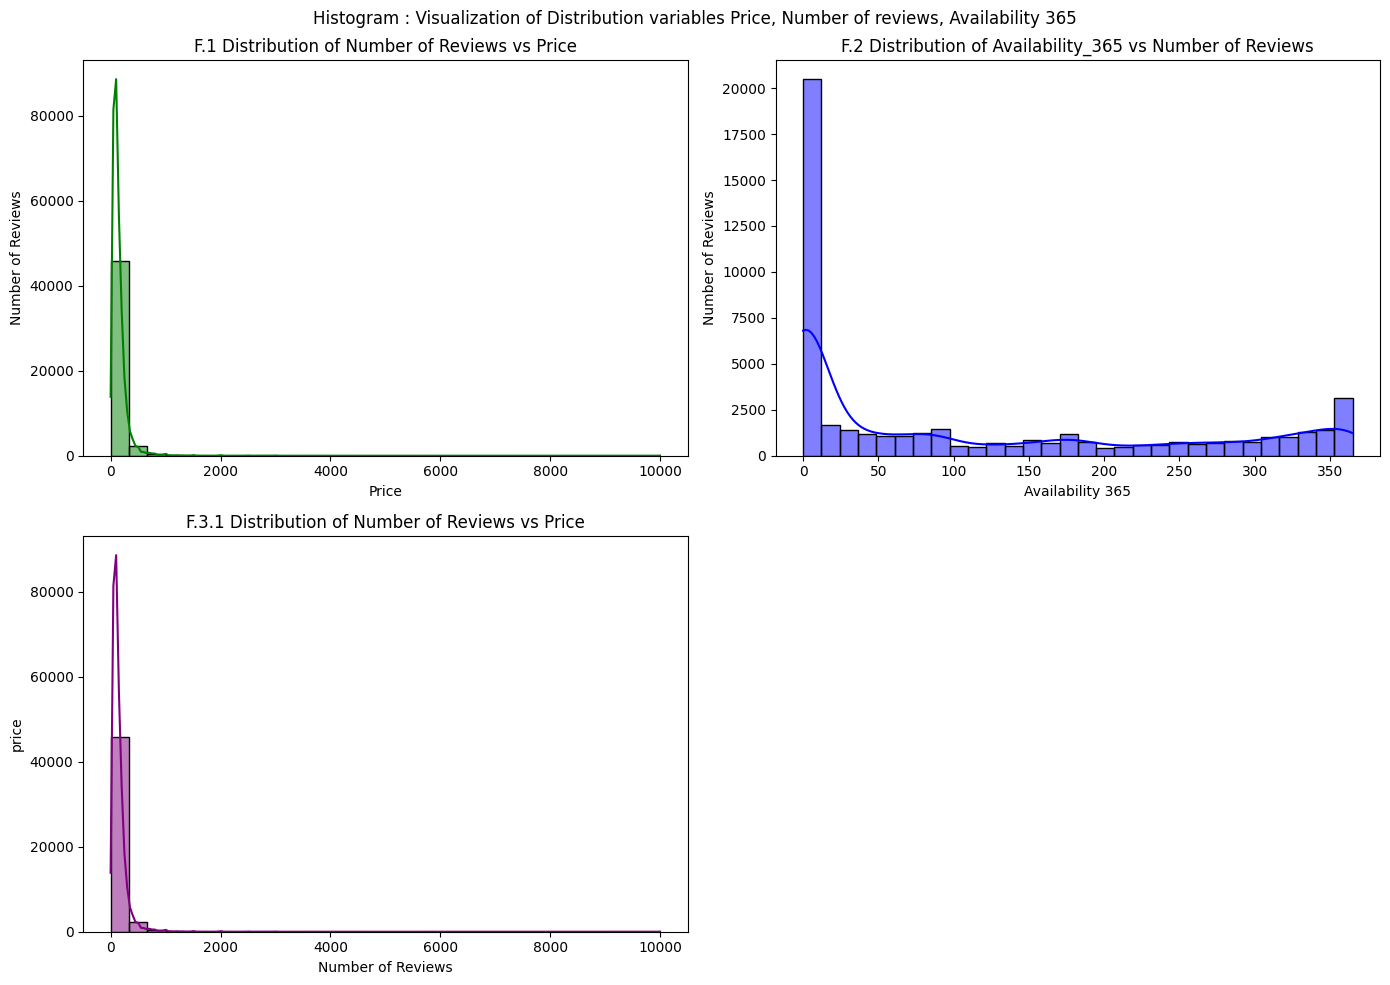

In [20]:
#Visualization of distribution will use histogram
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.histplot(clone_AB_NYC['price'], kde=True, bins=30, color='green', edgecolor='black')
plt.title("F.1 Distribution of Number of Reviews vs Price")
plt.xlabel('Price')
plt.ylabel("Number of Reviews")
# plt.savefig("F.1 Distribution of Number of Reviews vs Price.png")

plt.subplot(2, 2, 2)
sns.histplot(clone_AB_NYC['availability_365'], kde=True, bins=30, color='blue', edgecolor='black')
plt.title("F.2 Distribution of Availability_365 vs Number of Reviews")
plt.xlabel('Availability 365')
plt.ylabel("Number of Reviews")
# plt.savefig("F.2 Distribution of Availability_365 vs Number of Reviews.pdf")

plt.subplot(2, 2, 3)
sns.histplot(clone_AB_NYC['price'], kde=True, bins=30, color='purple', edgecolor='black')
plt.title("F.3.1 Distribution of Number of Reviews vs Price")
plt.xlabel('Number of Reviews')
plt.ylabel("price")
# plt.savefig("F.3 Distribution of Number of Reviews vs Price.png")

plt.suptitle('Histogram : Visualization of Distribution variables Price, Number of reviews, Availability 365')
plt.tight_layout()
plt.show()
plt.close()

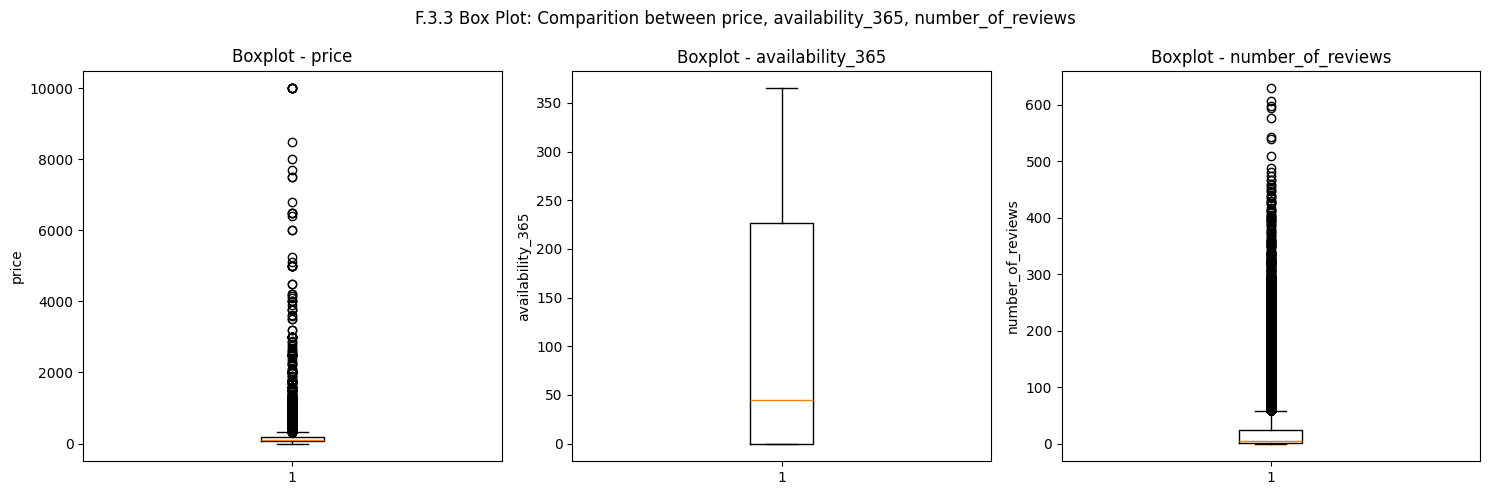

In [21]:
#Box plot
cols = ['price', 'availability_365', 'number_of_reviews']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cols):
    axes[i].boxplot(clone_AB_NYC[col].dropna())
    axes[i].set_title(f'Boxplot - {col}')
    axes[i].set_ylabel(col)

plt.suptitle('F.3.3 Box Plot: Comparition between price, availability_365, number_of_reviews')
# savefig('F.3.3 Box Plot: Comparition between price, availability_365, number_of_reviews.png')
plt.tight_layout()
plt.show()
plt.close()

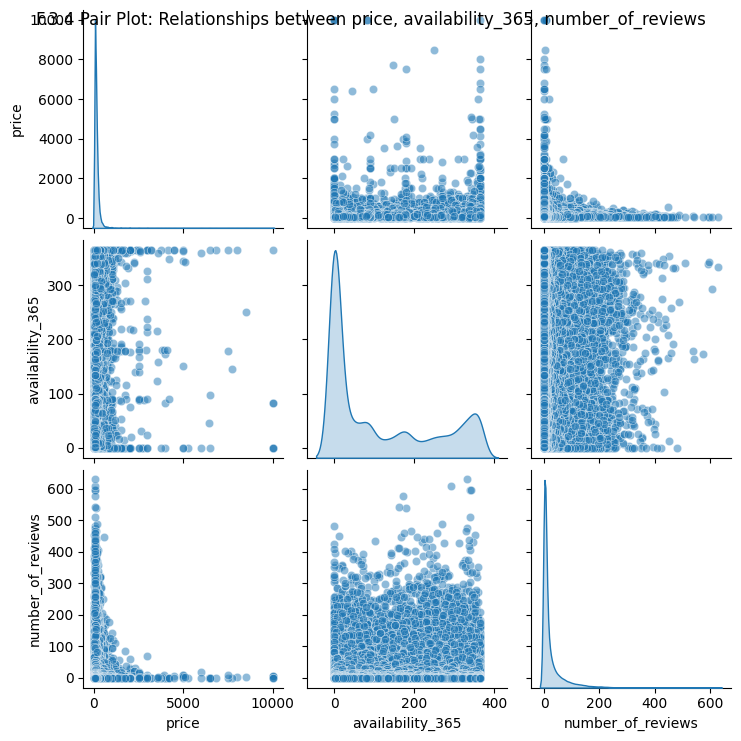

In [22]:
#Pair Plot
cols = ['price', 'availability_365', 'number_of_reviews']

sns.pairplot(clone_AB_NYC[cols], diag_kind='kde', plot_kws={'alpha': 0.5}, corner=False)

plt.suptitle('F.3.4 Pair Plot: Relationships between price, availability_365, number_of_reviews')
# savefig('F.3.4 Pair Plot: Relationships between price, availability_365, number_of_reviews.png')
plt.show()
plt.close()

Total anomalies per variable anomaly
 1    46450
-1     2445
Name: count, dtype: int64


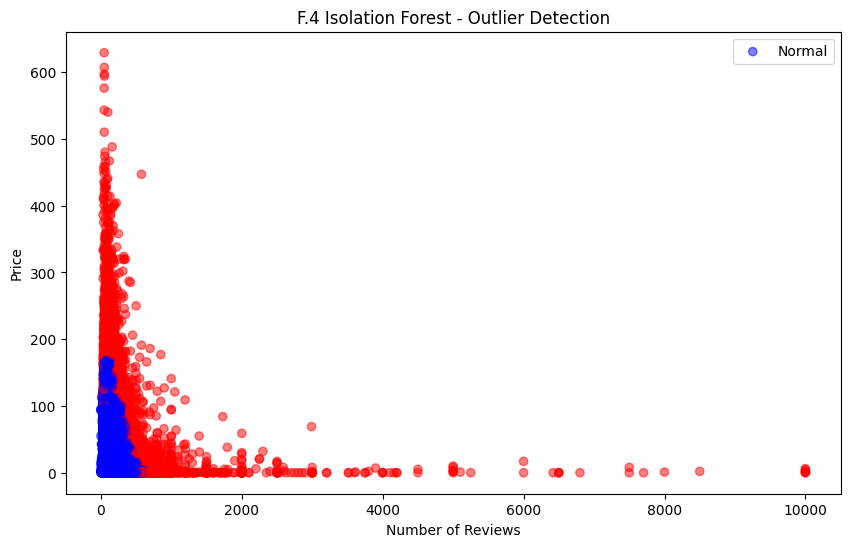

In [23]:
#Handling outliers/Detect and treat outliers using techniques Isolation Forest
from sklearn.ensemble import IsolationForest
# Select numeric columns
features = clone_AB_NYC[['price', 'number_of_reviews', 'availability_365']]
# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
clone_AB_NYC['anomaly'] = iso_forest.fit_predict(features)
# -1 = outlier, 1 = normal
print(f'Total anomalies per variable',clone_AB_NYC['anomaly'].value_counts())
#visualization outliers
plt.figure(figsize=(10,6))
colors = clone_AB_NYC['anomaly'].map({1: 'blue', -1: 'red'})
plt.scatter(clone_AB_NYC['price'], clone_AB_NYC['number_of_reviews'], c=colors, alpha=0.5)
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.title('F.4 Isolation Forest - Outlier Detection')
plt.legend(['Normal', 'Outlier'])
# savefig("F.4 Isolation Forest - Outlier Detection.png")
plt.show()
plt.close()

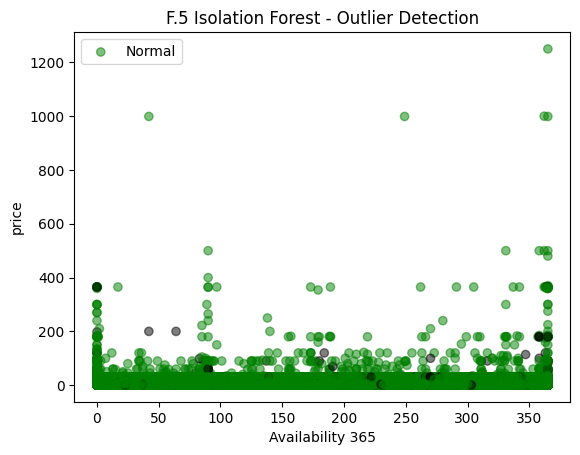

In [24]:
colors = clone_AB_NYC['anomaly'].map({1: 'green', -1: 'black'})
plt.scatter(clone_AB_NYC['availability_365'], clone_AB_NYC['minimum_nights'], c=colors, alpha=0.5)
plt.xlabel('Availability 365')
plt.ylabel('price')
plt.title('F.5 Isolation Forest - Outlier Detection')
plt.legend(['Normal', 'Outlier'])
# savefig("F.5 Isolation Forest - Outlier Detection.png")
plt.show()
plt.close()

In [25]:
#Inspect outliers
outliers = clone_AB_NYC[clone_AB_NYC['anomaly'] == -1]
print(f'Description of outliers',outliers[['price', 'number_of_reviews','availability_365']].head())


Description of outliers     price  number_of_reviews  availability_365
3      89                270               194
7      79                430               220
11     85                188                39
12     89                167               314
16    215                198               321


In [26]:
#How significant are my anomalies in my data
import numpy as np

cols = ['price', 'availability_365', 'number_of_reviews']

Q1 = clone_AB_NYC[cols].quantile(0.25)
Q3 = clone_AB_NYC[cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((clone_AB_NYC[cols] < lower) | (clone_AB_NYC[cols] > upper)).sum()
print(f'Information of outliers details:\n',outliers)

Information of outliers details:
 price                2972
availability_365        0
number_of_reviews    6021
dtype: int64


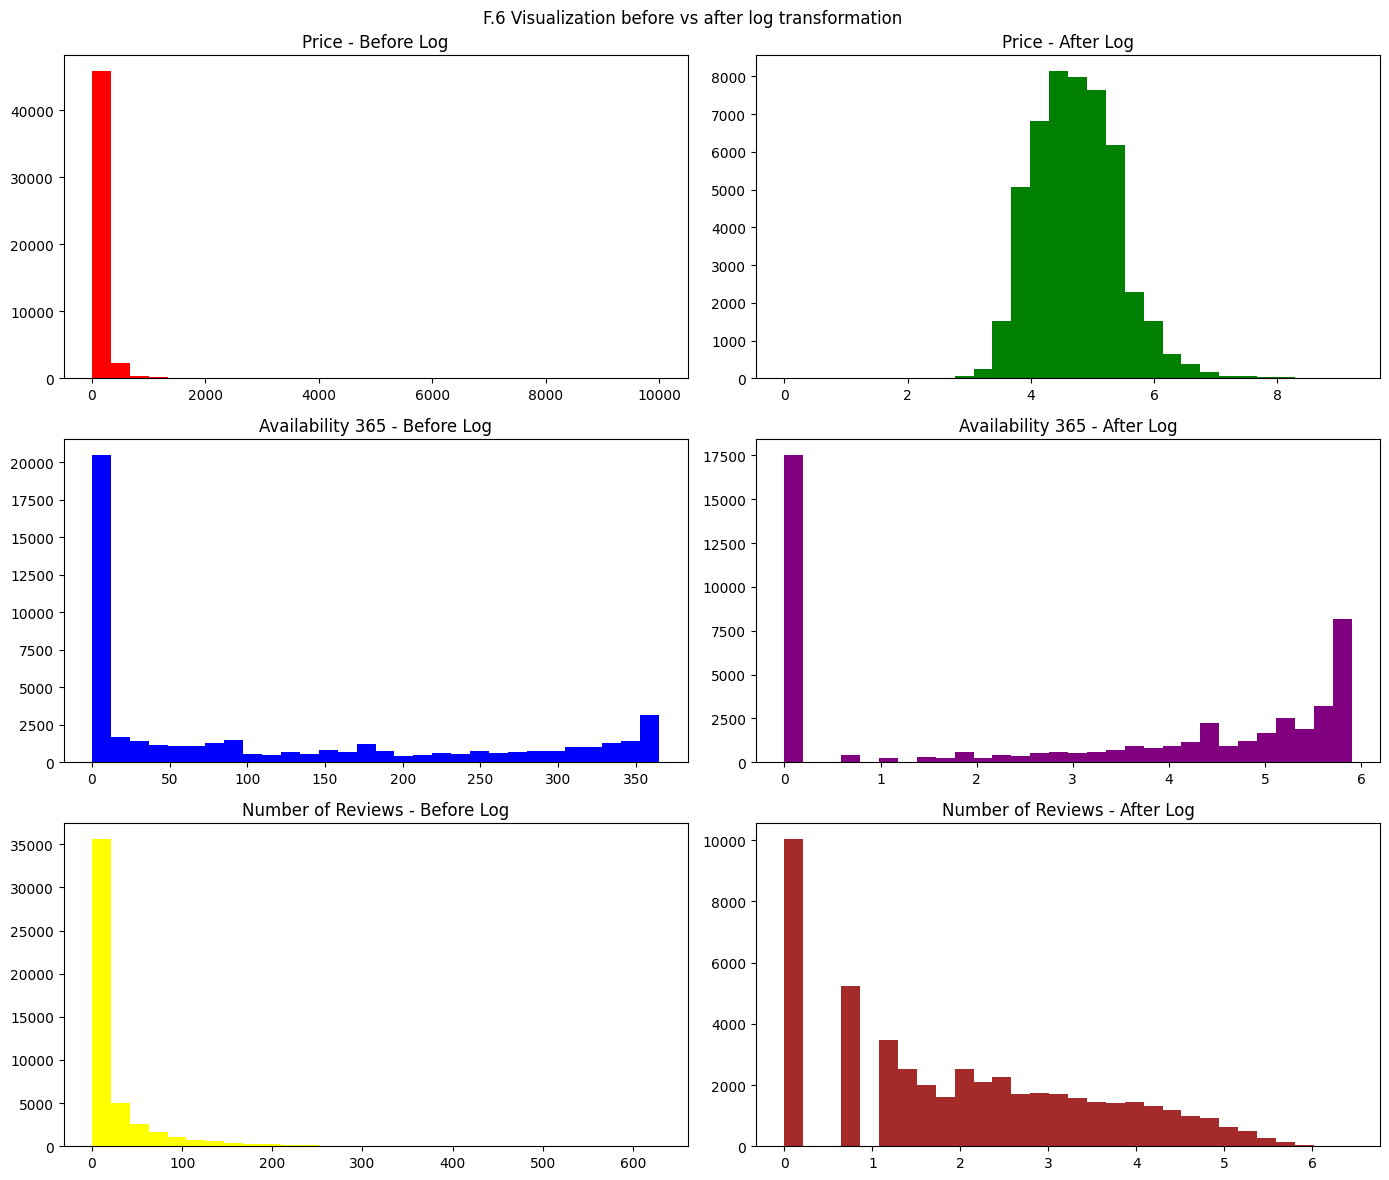

In [27]:
#Apply transforming anomalies by compressing the scale of the data
# Apply log transformation to skewed columns
clone_AB_NYC['price_log'] = np.log1p(clone_AB_NYC['price'])
clone_AB_NYC['number_of_reviews_log'] = np.log1p(clone_AB_NYC['number_of_reviews'])
clone_AB_NYC['availability_365_log'] = np.log1p(clone_AB_NYC['availability_365'])
# Visualize before vs after:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Price
axes[0, 0].hist(clone_AB_NYC['price'], bins=30, color='red')
axes[0, 0].set_title('Price - Before Log')

axes[0, 1].hist(clone_AB_NYC['price_log'], bins=30, color='green')
axes[0, 1].set_title('Price - After Log')

# Availability 365
axes[1, 0].hist(clone_AB_NYC['availability_365'], bins=30, color='blue')
axes[1, 0].set_title('Availability 365 - Before Log')

axes[1, 1].hist(clone_AB_NYC['availability_365_log'], bins=30, color='purple')
axes[1, 1].set_title('Availability 365 - After Log')

# Number of Reviews
axes[2, 0].hist(clone_AB_NYC['number_of_reviews'], bins=30, color='yellow')
axes[2, 0].set_title('Number of Reviews - Before Log')

axes[2, 1].hist(clone_AB_NYC['number_of_reviews_log'], bins=30, color='brown')
axes[2, 1].set_title('Number of Reviews - After Log')

plt.suptitle('F.6 Visualization before vs after log transformation ')
# savefig("F.6 Visualization log transformation before vs after.png")
plt.tight_layout()
plt.show()
plt.close()

In [28]:
#Check the impact Outliers after log transformation
# to reveal skewness, outliers, and central tendency.
# checkin skew of the data /checking the impact of the variables.
print("Skewness Before Log Transformation:")
print(clone_AB_NYC[['price', 'number_of_reviews', 'availability_365']].skew())

print("\nSkewness After Log Transformation:")
print(clone_AB_NYC[['price_log', 'number_of_reviews_log', 'availability_365_log']].skew())

Skewness Before Log Transformation:
price                19.118939
number_of_reviews     3.690635
availability_365      0.763408
dtype: float64

Skewness After Log Transformation:
price_log                0.553105
number_of_reviews_log    0.362924
availability_365_log    -0.198242
dtype: float64


In [29]:
#Standarization/Normalization
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(clone_AB_NYC[['price', 'availability_365', 'number_of_reviews']])

# convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=['price', 'availability_365', 'number_of_reviews'])
print(X_scaled.head())

#verification
print(X_scaled.describe())

      price  availability_365  number_of_reviews
0  0.405660          1.409692           0.173913
1  1.122642          1.365639           1.739130
2  0.415094          1.409692          -0.217391
3 -0.160377          0.656388          11.521739
4 -0.245283         -0.198238           0.173913
              price  availability_365  number_of_reviews
count  48895.000000      48895.000000       48895.000000
mean       0.440761          0.298596           0.794542
std        2.265605          0.579834           1.936982
min       -1.000000         -0.198238          -0.217391
25%       -0.349057         -0.198238          -0.173913
50%        0.000000          0.000000           0.000000
75%        0.650943          0.801762           0.826087
max       93.339623          1.409692          27.130435


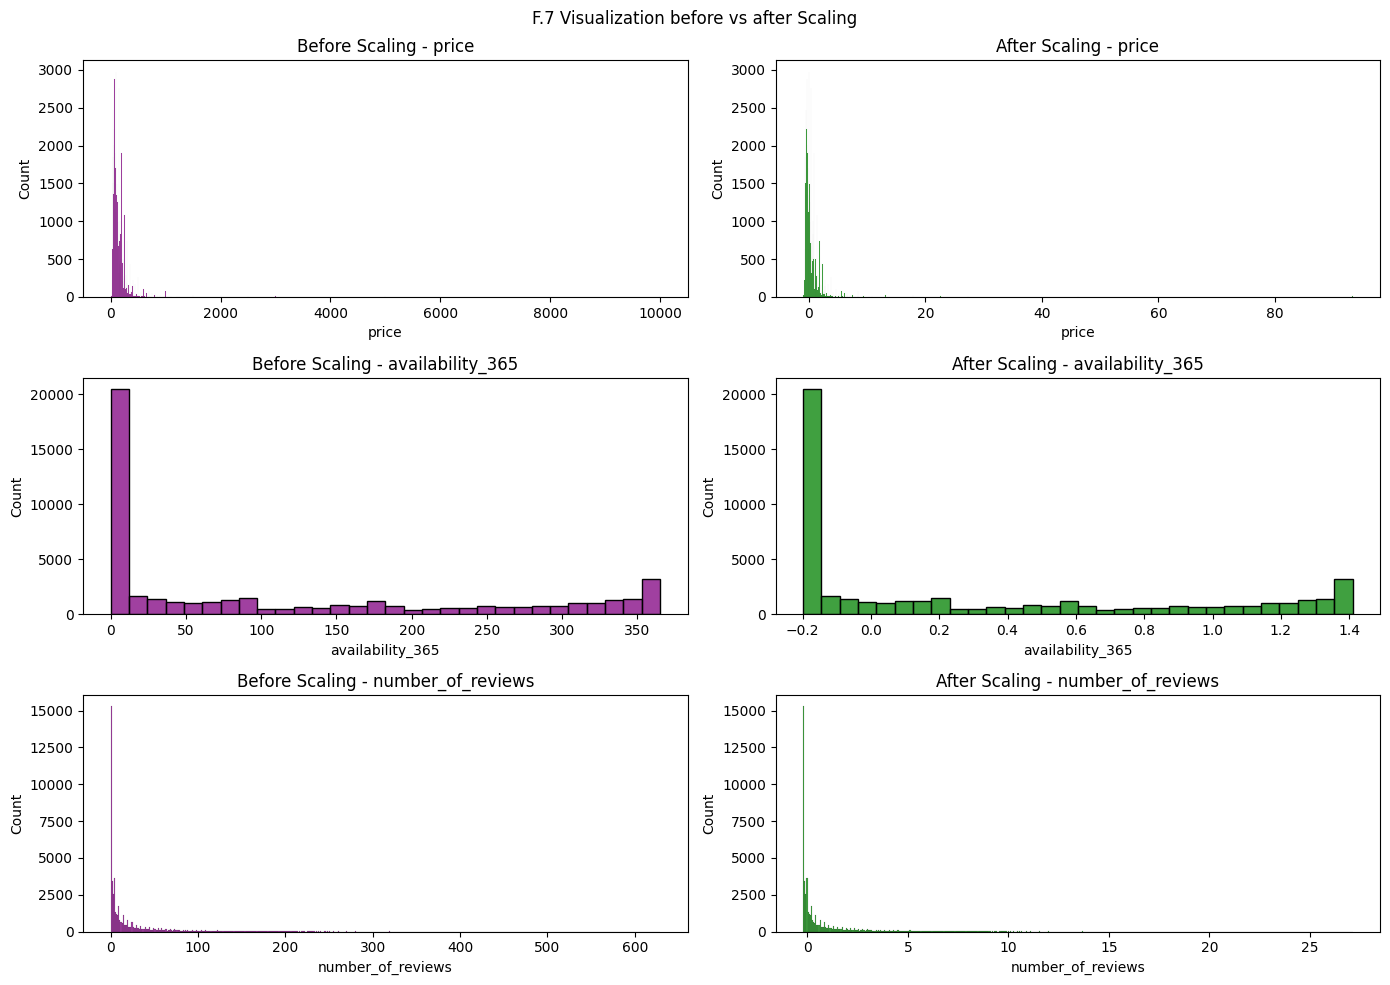

In [30]:
#Visualization before and after
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['price', 'availability_365', 'number_of_reviews']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, col in enumerate(cols):
    # Before scaling
    sns.histplot(data=clone_AB_NYC, x=col, ax=axes[i, 0], color='purple')
    axes[i, 0].set_title(f'Before Scaling - {col}')

    # After scaling
    sns.histplot(data=X_scaled, x=col, ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'After Scaling - {col}')

plt.suptitle('F.7 Visualization before vs after Scaling')
# savefig("F.7 Visualization before vs after Scaling.png")
plt.tight_layout()
plt.show()
plt.close()

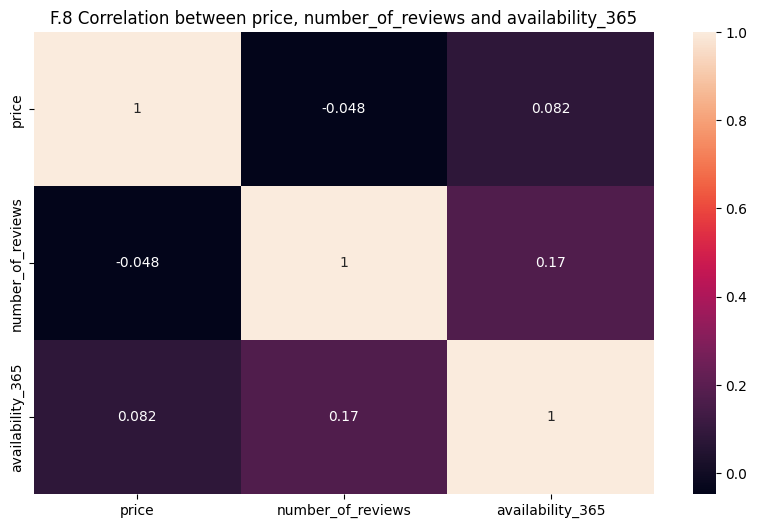

In [31]:
#Analyze correlations between 'number_of_reviews', 'price', and 'availability_365'.
# Visualize the Data heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(AB_NYC[['price', 'number_of_reviews', 'availability_365']].corr(), annot=True, cmap='rocket')

plt.title('F.8 Correlation between price, number_of_reviews and availability_365')
# savefig('F.8 Correlation between price, number_of_reviews and availability_365.png')
plt.show()
plt.close()

In [32]:
#Analysis the correlation and P- Value
from scipy.stats import pearsonr

correlation, p_value = pearsonr(AB_NYC['price'], AB_NYC['number_of_reviews'])
print(f"P-value: {p_value}")

print(f"Correlation between \nnumber_of_reviews, \nprice, and \navailability_365. : {correlation}")

P-value: 2.689737394484035e-26
Correlation between 
number_of_reviews, 
price, and 
availability_365. : -0.04795422658266221


In [33]:
#Advanced Data Analysis Techniques
#Prediction for each number_ of _reviews what is the proportion my occupancy increase (availability)
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [34]:
#Split data /features and target 'number_of_reviews', 'price', 'availability_365'
X = clone_AB_NYC[['number_of_reviews']]
y = clone_AB_NYC['availability_365']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
#Initialize the models
decision_tree = DecisionTreeClassifier(random_state=42)
knn= KNeighborsClassifier()

# Train the models
decision_tree.fit(X_train, y_train)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [36]:
#Make predictions (i.e. test the models)
y_pred_dt = decision_tree.predict(X_test)
y_pred_knn = knn.predict(X_test)

In [37]:
#Calculate and print Performance Metrics (accuracy and classification_report) for each model
#accuracy
# calculate DecisionTree and KNN = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(f"KNN Accuracy:           {acc_knn:.4f}")

print("Accuracy Decision Tree\n:", acc_dt)
print("Accuracy KNeighbors:\n", acc_knn)

#classification_report
print("\nDecision Tree Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

print("\nKNN Report:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

Decision Tree Accuracy: 0.3640
KNN Accuracy:           0.3464
Accuracy Decision Tree
: 0.36404540341548214
Accuracy KNeighbors:
 0.3463544329686062

Decision Tree Report:
              precision    recall  f1-score   support

           0       0.38      0.99      0.55      3580
           1       0.09      0.01      0.02        81
           2       0.00      0.00      0.00        49
           3       0.00      0.00      0.00        61
           4       0.00      0.00      0.00        51
           5       0.00      0.00      0.00        60
           6       0.00      0.00      0.00        47
           7       0.00      0.00      0.00        51
           8       0.00      0.00      0.00        40
           9       0.00      0.00      0.00        43
          10       0.00      0.00      0.00        34
          11       0.00      0.00      0.00        29
          12       0.00      0.00      0.00        28
          13       0.00      0.00      0.00        32
          14      

In [38]:
#Unsupervised predictions
#split data /features and target 'number_of_reviews', 'price', 'availability_365'
#first find the best n_clusters = k
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

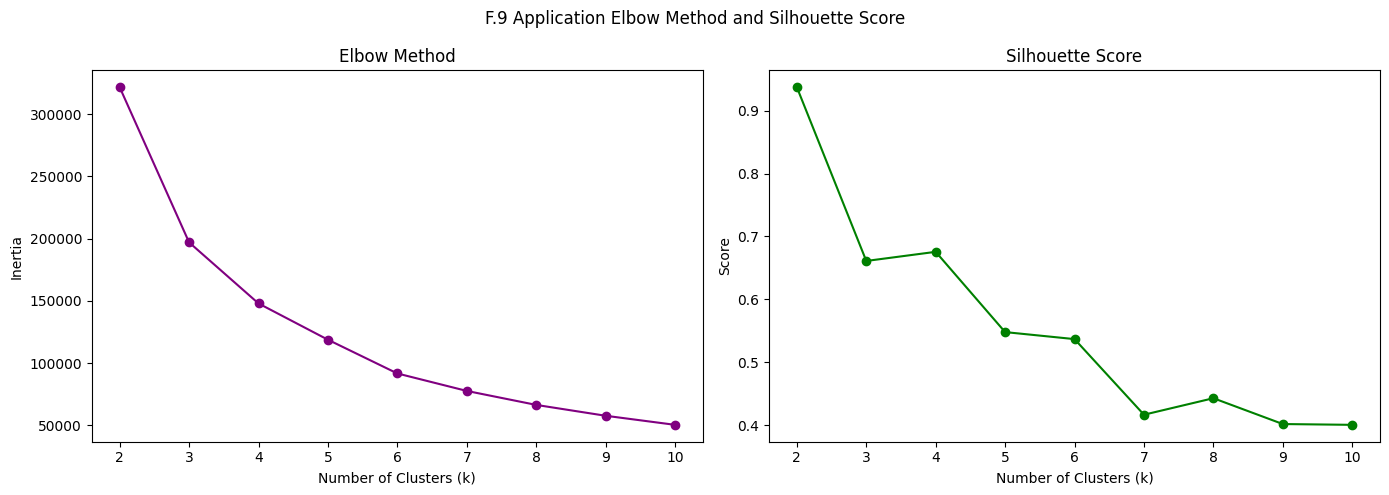

In [40]:
# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_range, inertias, marker='o', color='purple')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

# Silhouette
axes[1].plot(k_range, silhouette_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')


plt.suptitle('F.9 Application Elbow Method and Silhouette Score')
# savefig('F.9 Application Elbow Method and Silhouette Score.png')
plt.tight_layout()
plt.show()
plt.close()

In [41]:
# Print best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best k by Silhouette Score: {best_k}")

Best k by Silhouette Score: 2


In [42]:
#Split data /features and target 'number_of_reviews', 'price', 'availability_365'
X = clone_AB_NYC[['number_of_reviews']]
y = clone_AB_NYC['availability_365']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
#Apply the model Decision Tree Classifier
#Decision Tree Classifier to predict the number of reviews impact in the availability
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

#Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dtc = classification_report(y_test, y_pred_dt,zero_division=0)

print("Decision Tree Accuracy:", accuracy_dt)
print("\nClassification Report for Decision Tree:\n", classification_report(y_test, y_pred_dt, zero_division=0))

# KMeans Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)
groupTag = kmeans.labels_
silhouette_avg_kmeans = silhouette_score(X, groupTag)

# Print the performance metrics and results
print("\nDecision Tree Classifier:")
print(f"Accuracy: {accuracy_dt:.2f}")
print("Classification Report:", classification_report(y_test, y_pred_dt, zero_division=0))
print(report_dtc)

print("\nKMeans Clustering:")
print(f"Silhouette Score: {silhouette_avg_kmeans:.2f}")

# Evaluate the Model using silhouette score
score = silhouette_score(X, kmeans.labels_)
print(f'Silhouette Score: {score}')

Decision Tree Accuracy: 0.36404540341548214

Classification Report for Decision Tree:
               precision    recall  f1-score   support

           0       0.38      0.99      0.55      3580
           1       0.09      0.01      0.02        81
           2       0.00      0.00      0.00        49
           3       0.00      0.00      0.00        61
           4       0.00      0.00      0.00        51
           5       0.00      0.00      0.00        60
           6       0.00      0.00      0.00        47
           7       0.00      0.00      0.00        51
           8       0.00      0.00      0.00        40
           9       0.00      0.00      0.00        43
          10       0.00      0.00      0.00        34
          11       0.00      0.00      0.00        29
          12       0.00      0.00      0.00        28
          13       0.00      0.00      0.00        32
          14       0.00      0.00      0.00        45
          15       0.00      0.00      0.00     